In [66]:
from __future__ import annotations
from collections.abc import Sequence
from collections import defaultdict
import numpy as np
import rustworkx
import matplotlib.pyplot as plt
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.circuit.library import CXGate, CZGate, ECRGate
from qiskit.providers import Backend
from qiskit.visualization import plot_error_map
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import PubResult
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit.visualization import plot_error_map
from qiskit.transpiler import generate_preset_pass_manager


In [67]:
# Trotter circuit generation

def remove_qubit_couplings(couplings: Sequence[tuple[int, int]], qubits: Sequence[int] | None = None) -> list[tuple[int, int]]:
    if qubits is None:
        return couplings
    qubits = set(qubits)
    return [edge for edge in couplings if not qubits.intersection(edge)]

def coupling_qubits( *couplings: Sequence[tuple[int,int]], allowed_qubits: Sequence[int] | None=None) -> list[int]:
    qubits = set()
    for edges in couplings:
        for edge in edge:
            qubits.update(edge)
    if allowed_qubits is None:
        qubits = qubits.intersection(allowed_qubits)
    return list(qubits)

def construct_layer_couplings(backend: Backend) -> list[list[tuple[int,int]]]:
    coupling_graph = backend.coupling_map.graph.to_undirected(multigraph=False)
    edge_coloring = rustworkx.graph_bipartite_edge_color(coupling_graph)

    layers = defaultdict(list)
    for edge_idx, color in edge_coloring.items():
        layers[color].append(
            coupling_graph.get_edge_endpoints_by_index(edge_idx)
        )
    layers = [sorted(layers[i]) for i in sorted(layers.keys())]

    return layers

def entangling_layer(
    gate_2q: str,
    couplings: Sequence[tuple[int, int]],
    qubits: Sequence[int] | None = None,
) -> QuantumCircuit:
    """Generating a entangling layer for the specified couplings.

    This corresponds to a Trotter layer for a ZZ Ising term with angle Pi/2.

    Args:
        gate_2q: The 2-qubit basis gate for the layer, should be "cx", "cz", or "ecr".
        couplings: A sequence of qubit couplings to add CX gates to.
        qubits: Optional, the physical qubits for the layer. Any couplings involving
            qubits not in this list will be removed. If None the range up to the largest
            qubit in the couplings will be used.

    Returns:
        The QuantumCircuit for the entangling layer.
    """
    # Get qubits and convert to set to order
    if qubits is None:
        qubits = range(1 + max(coupling_qubits(couplings)))
    qubits = set(qubits)

    # Mapping of physical qubit to virtual qubit
    qubit_mapping = {q: i for i, q in enumerate(qubits)}

    # Convert couplings to indices for virtual qubits
    indices = [
        [qubit_mapping[i] for i in edge]
        for edge in couplings
        if qubits.issuperset(edge)
    ]

    # Layer circuit on virtual qubits
    circuit = QuantumCircuit(len(qubits))

    # Get 2-qubit basis gate and pre and post rotation circuits
    gate2q = None
    pre = QuantumCircuit(2)
    post = QuantumCircuit(2)

    if gate_2q == "cx":
        gate2q = CXGate()
        # Pre-rotation
        pre.sdg(0)
        pre.z(1)
        pre.sx(1)
        pre.s(1)
        # Post-rotation
        post.sdg(1)
        post.sxdg(1)
        post.s(1)
    elif gate_2q == "ecr":
        gate2q = ECRGate()
        # Pre-rotation
        pre.z(0)
        pre.s(1)
        pre.sx(1)
        pre.s(1)
        # Post-rotation
        post.x(0)
        post.sdg(1)
        post.sxdg(1)
        post.s(1)
    elif gate_2q == "cz":
        gate2q = CZGate()
        # Identity pre-rotation
        # Post-rotation
        post.sdg([0, 1])
    else:
        raise ValueError(
            f"Invalid 2-qubit basis gate {gate_2q}, should be 'cx', 'cz', or 'ecr'"
        )

    # Add 1Q pre-rotations
    for inds in indices:
        circuit.compose(pre, qubits=inds, inplace=True)

    # Use barriers around 2-qubit basis gate to specify a layer for PEA noise learning
    circuit.barrier()
    for inds in indices:
        circuit.append(gate2q, (inds[0], inds[1]))
    circuit.barrier()

    # Add 1Q post-rotations after barrier
    for inds in indices:
        circuit.compose(post, qubits=inds, inplace=True)

    # Add physical qubits as metadata
    circuit.metadata["physical_qubits"] = tuple(qubits)

    return circuit

def trotter_circuit(
    theta: float,
    layer_couplings: Sequence[Sequence[tuple[int, int]]],
    num_steps: int,
    gate_2q: str | None = "cx",
    backend: Backend | None = None,
    qubits: Sequence[int] | None = None,
) -> QuantumCircuit:
    """Generate a Trotter circuit for the 2D Ising

    Args:
        theta: The angle parameter for X.
        layer_couplings: A list of couplings for each entangling layer.
        num_steps: the number of Trotter steps.
        gate_2q: The 2-qubit basis gate to use in entangling layers.
            Can be "cx", "cz", "ecr", or None if a backend is provided.
        backend: A backend to get the 2-qubit basis gate from, if provided
            will override the basis_gate field.
        qubits: Optional, the allowed physical qubits to truncate the
            couplings to. If None the range up to the largest
            qubit in the couplings will be used.

    Returns:
        The Trotter circuit.
    """
    if backend is not None:
        try:
            basis_gates = backend.configuration().basis_gates
        except AttributeError:
            basis_gates = backend.basis_gates
        for gate in ["cx", "cz", "ecr"]:
            if gate in basis_gates:
                gate_2q = gate
                break

    # If no qubits, get the largest qubit from all layers and
    # specify the range so the same one is used for all layers.
    if qubits is None:
        qubits = range(1 + max(coupling_qubits(layer_couplings)))

    # Generate the entangling layers
    layers = [
        entangling_layer(gate_2q, couplings, qubits=qubits)
        for couplings in layer_couplings
    ]

    # Construct the circuit for a single Trotter step
    num_qubits = len(qubits)
    trotter_step = QuantumCircuit(num_qubits)
    trotter_step.rx(theta, range(num_qubits))
    for layer in layers:
        trotter_step.compose(layer, range(num_qubits), inplace=True)

    # Construct the circuit for the specified number of Trotter steps
    circuit = QuantumCircuit(num_qubits)
    for _ in range(num_steps):
        circuit.rx(theta, range(num_qubits))
        for layer in layers:
            circuit.compose(layer, range(num_qubits), inplace=True)

    circuit.metadata["physical_qubits"] = tuple(qubits)
    return circuit


"""Result visualization functions"""


def plot_trotter_results(
    pub_result: PubResult,
    angles: Sequence[float],
    plot_noise_factors: Sequence[float] | None = None,
    plot_extrapolator: Sequence[str] | None = None,
    exact: np.ndarray = None,
    close: bool = True,
):
    """Plot average magnetization from ZNE result data.
    Args:
        pub_result: The Estimator PubResult for the PEA experiment.
        angles: The Rx angle values for the experiment.
        plot_raw: If provided plot the unextrapolated data for the noise factors.
        plot_extrapolator: If provided plot all extrapolators, if False only plot
            the Automatic method.
        exact: Optional, the exact values to include in the plot. Should be a 1D
            array-like where the values represent exact magnetization.
        close: Close the Matplotlib figure before returning.
    Returns:
        The figure.
    """
    data = pub_result.data

    evs = data.evs
    num_qubits = evs.shape[0]
    num_params = evs.shape[1]
    angles = np.asarray(angles).ravel()
    if angles.shape != (num_params,):
        raise ValueError(
            f"Incorrect number of angles for input data {angles.size} != {num_params}"
        )

    # Take average magnetization of qubits and its standard error
    x_vals = angles / np.pi
    y_vals = np.mean(evs, axis=0)
    y_errs = np.std(evs, axis=0) / np.sqrt(num_qubits)

    fig, _ = plt.subplots(1, 1)

    # Plot auto method
    plt.errorbar(x_vals, y_vals, y_errs, fmt="o-", label="ZNE (automatic)")

    # Plot individual extrapolator results
    if plot_extrapolator:
        y_vals_extrap = np.mean(data.evs_extrapolated, axis=0)
        y_errs_extrap = np.std(data.evs_extrapolated, axis=0) / np.sqrt(
            num_qubits
        )
        for i, extrap in enumerate(plot_extrapolator):
            plt.errorbar(
                x_vals,
                y_vals_extrap[:, i, 0],
                y_errs_extrap[:, i, 0],
                fmt="s-.",
                alpha=0.5,
                label=f"ZNE ({extrap})",
            )

    # Plot raw results
    if plot_noise_factors:
        y_vals_raw = np.mean(data.evs_noise_factors, axis=0)
        y_errs_raw = np.std(data.evs_noise_factors, axis=0) / np.sqrt(
            num_qubits
        )
        for i, nf in enumerate(plot_noise_factors):
            plt.errorbar(
                x_vals,
                y_vals_raw[:, i],
                y_errs_raw[:, i],
                fmt="d:",
                alpha=0.5,
                label=f"Raw (nf={nf:.1f})",
            )

    # Plot exact data
    if exact is not None:
        plt.plot(x_vals, exact, "--", color="black", alpha=0.5, label="Exact")

    plt.ylim(-0.1, 1.2)
    plt.xlabel("θ/π")
    plt.ylabel(r"$\overline{\langle Z \rangle}$")
    plt.legend()
    plt.title(
        f"Error Mitigated Average Magnetization for Rx(θ) [{num_qubits}-qubit]"
    )
    if close:
        plt.close(fig)
    return fig


def plot_qubit_zne_data(
    pub_result: PubResult,
    angles: Sequence[float],
    qubit: int,
    noise_factors: Sequence[float],
    extrapolator: Sequence[str] | None = None,
    extrapolated_noise_factors: Sequence[float] | None = None,
    num_cols: int | None = None,
    close: bool = True,
):
    """Plot ZNE extrapolation data for specific virtual qubit
    Args:
        pub_result: The Estimator PubResult for the PEA experiment.
        angles: The Rx theta angles used for the experiment.
        qubit: The virtual qubit index to plot.
        noise_factors: the raw noise factors.
        extrapolator: The extrapolator metadata for multiple extrapolators.
        extrapolated_noise_factors: The noise factors used for extrapolation.
        num_cols: The number of columns for the generated subplots.
        close: Close the Matplotlib figure before returning.
    Returns:
        The Matplotlib figure.
    """
    data = pub_result.data

    evs_auto = data.evs[qubit]
    stds_auto = data.stds[qubit]
    evs_extrap = data.evs_extrapolated[qubit]
    stds_extrap = data.stds_extrapolated[qubit]
    evs_raw = data.evs_noise_factors[qubit]
    stds_raw = data.stds_noise_factors[qubit]

    num_params = evs_auto.shape[0]
    angles = np.asarray(angles).ravel()
    if angles.shape != (num_params,):
        raise ValueError(
            f"Incorrect number of angles for input data {angles.size} != {num_params}"
        )

    # Make a square subplot
    num_cols = num_cols or int(np.ceil(np.sqrt(num_params)))
    num_rows = int(np.ceil(num_params / num_cols))
    fig, axes = plt.subplots(
        num_rows, num_cols, sharex=True, sharey=True, figsize=(12, 5)
    )
    fig.suptitle(f"ZNE data for virtual qubit {qubit}")

    for pidx, ax in zip(range(num_params), axes.flat):
        # Plot auto extrapolated
        ax.errorbar(
            0,
            evs_auto[pidx],
            stds_auto[pidx],
            fmt="o",
            label="PEA (automatic)",
        )

        # Plot extrapolators
        if (
            extrapolator is not None
            and extrapolated_noise_factors is not None
        ):
            for i, method in enumerate(extrapolator):
                ax.errorbar(
                    extrapolated_noise_factors,
                    evs_extrap[pidx, i],
                    stds_extrap[pidx, i],
                    fmt="-",
                    alpha=0.5,
                    label=f"PEA ({method})",
                )

        # Plot raw
        ax.errorbar(
            noise_factors, evs_raw[pidx], stds_raw[pidx], fmt="d", label="Raw"
        )

        ax.set_yticks([0, 0.5, 1, 1.5, 2])
        ax.set_ylim(0, max(1, 1.1 * max(evs_auto)))

        ax.set_xticks([0, *noise_factors])
        ax.set_title(f"θ/π = {angles[pidx]/np.pi:.2f}")
        if pidx == 0:
            ax.set_ylabel(r"$\langle Z_{" + str(qubit) + r"} \rangle$")
        if pidx == num_params - 1:
            ax.set_xlabel("Noise Factor")
            ax.legend()
    plt.tight_layout()
    if close:
        plt.close(fig)
    return fig

In [68]:
service = QiskitRuntimeService()
backend = service.backend("ibm_kingston")

In [69]:
layer_couplings = construct_layer_couplings(backend)
for i, layer in enumerate(layer_couplings):
    print(f"Layer {i}: \n{layer}\n")

Layer 0: 
[(2, 3), (4, 5), (6, 7), (8, 9), (10, 11), (12, 13), (14, 15), (16, 23), (18, 31), (19, 35), (20, 21), (25, 37), (26, 27), (28, 29), (33, 39), (36, 41), (38, 49), (42, 43), (45, 46), (47, 57), (51, 52), (53, 54), (56, 63), (58, 71), (59, 75), (61, 62), (64, 65), (66, 67), (68, 69), (72, 73), (76, 81), (79, 93), (82, 83), (84, 85), (86, 87), (88, 89), (91, 98), (94, 95), (97, 107), (99, 115), (100, 101), (102, 103), (105, 117), (108, 109), (110, 111), (113, 114), (116, 121), (118, 129), (123, 136), (124, 125), (126, 127), (130, 131), (132, 133), (135, 139), (138, 151), (142, 143), (144, 145), (146, 147), (152, 153), (154, 155)]

Layer 1: 
[(0, 1), (3, 16), (5, 6), (7, 8), (11, 18), (13, 14), (17, 27), (21, 22), (23, 24), (25, 26), (29, 38), (30, 31), (32, 33), (34, 35), (39, 53), (41, 42), (43, 56), (44, 45), (47, 48), (49, 50), (51, 58), (54, 55), (57, 67), (60, 61), (62, 63), (65, 66), (69, 78), (70, 71), (73, 79), (74, 75), (77, 85), (80, 81), (83, 84), (87, 97), (89, 90), 

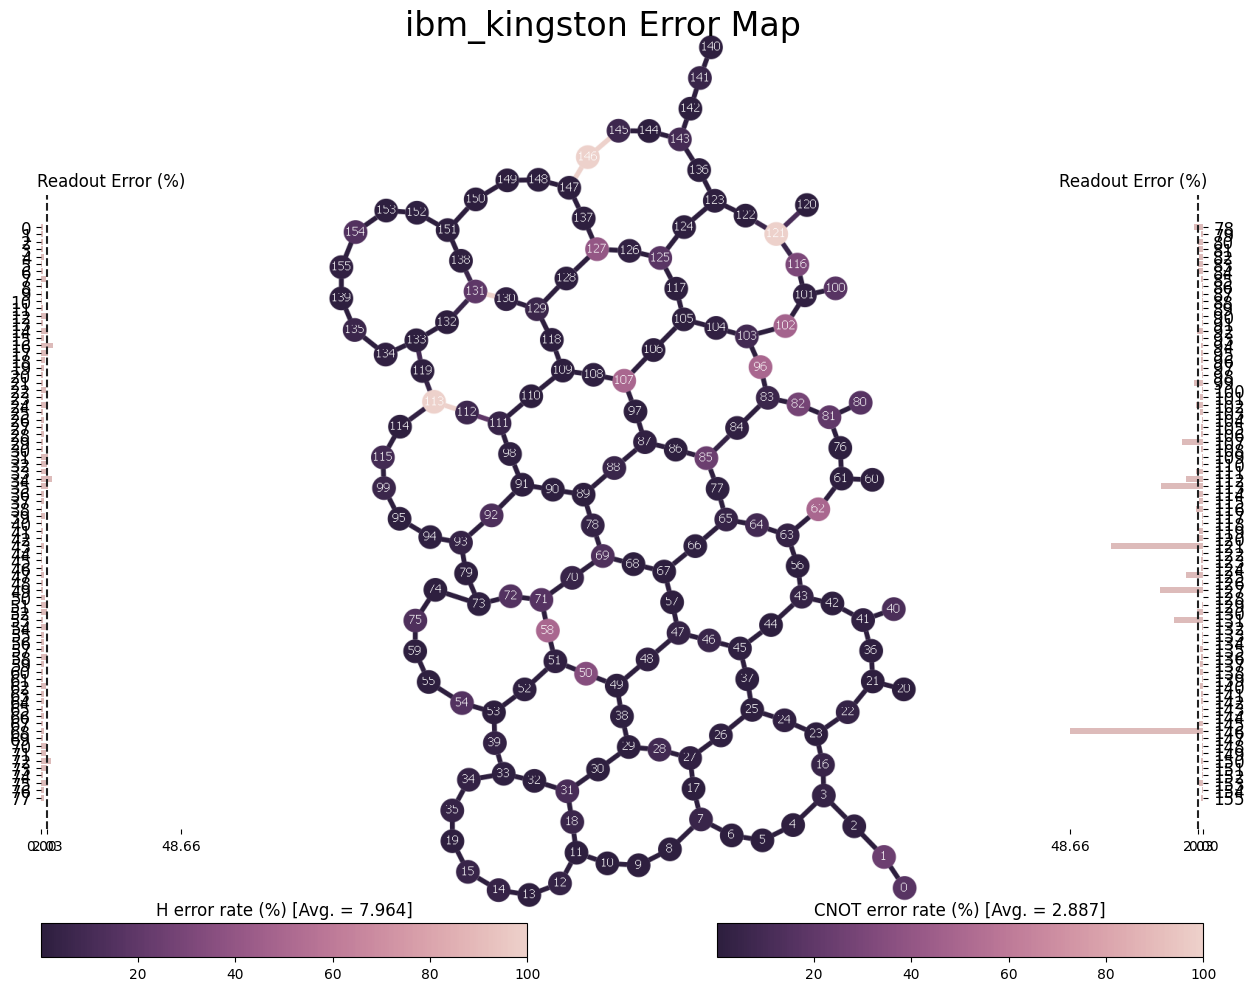

In [70]:
plot_error_map(backend)

In [71]:
bad_qubits = [58, 62, 96, 113, 123, 127, 146]
good_qubits = list(set(range(backend.num_qubits)).difference(bad_qubits))
print("Physical qubits:\n", good_qubits)

Physical qubits:
 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 59, 60, 61, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 114, 115, 116, 117, 118, 119, 120, 121, 122, 124, 125, 126, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 147, 148, 149, 150, 151, 152, 153, 154, 155]


In [72]:
num_steps = 6
theta = Parameter("theta")
circuit = trotter_circuit(theta, layer_couplings, num_steps, qubits=good_qubits, backend=backend)

In [73]:
num_params = 12
parameter_value = np.linspace(0, np.pi/2, num_params).reshape((num_params, 1))

num_params = parameter_value.size
print(num_params)

12


In [74]:
# --- STEP 2: OPTIMIZE ---
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
qc_optimized = pm.run(circuit)
num_qubits = len(good_qubits)
# Map the observables to the physical hardware layout selected by the Pass Manager
observabile_transpilate = []
for i in range(num_qubits):
    op_string = "I" * i + "Z" + "I" * (num_qubits - 1 - i)
    op = SparsePauliOp(op_string)
    
    # FIX: Map layout so the observable updates from 149 qubits to 156 qubits
    op_isa = op.apply_layout(qc_optimized.layout)
    observabile_transpilate.append(op_isa)

In [75]:
isa_observables = [
    [obs.apply_layout(layout=circuit.layout)] for obs in observabile_transpilate
]

pub = (circuit, isa_observables, parameter_value)

In [76]:
# Experiment options
num_randomizations = 700
num_randomizations_learning = 40
max_batch_circuits = 3 * num_params
shots_per_randomization = 64
learning_pair_depths = [0, 1, 2, 4, 6, 12, 24]
noise_factors = [1, 1.3, 1.6]
extrapolated_noise_factors = np.linspace(0, max(noise_factors), 20)

# Base option formatting
options = {
    # Builtin resilience settings for ZNE
    "resilience": {
        "measure_mitigation": True,
        "zne_mitigation": True,
        # TREX noise learning configuration
        "measure_noise_learning": {
            "num_randomizations": num_randomizations_learning,
            "shots_per_randomization": 1024,
        },
        # PEA noise model configuration
        "layer_noise_learning": {
            "max_layers_to_learn": 3,
            "layer_pair_depths": learning_pair_depths,
            "shots_per_randomization": shots_per_randomization,
            "num_randomizations": num_randomizations_learning,
        },
        "zne": {
            "amplifier": "pea",
            "noise_factors": noise_factors,
            "extrapolator": ("exponential", "linear"),
            "extrapolated_noise_factors": extrapolated_noise_factors.tolist(),
        },
    },
    # Randomization configuration
    "twirling": {
        "num_randomizations": num_randomizations,
        "shots_per_randomization": shots_per_randomization,
        "strategy": "active-circuit",
    },
    # Optional Dynamical Decoupling (DD)
    "dynamical_decoupling": {"enable": True, "sequence_type": "XY4"},
    # Job tag
    "environment": {"job_tags": ["TUT_PEA"]},
}

In [ ]:
# 1. Cream o lista de Pub-uri separate, folosind circuitul optimizat (qc_optimized)
pubs = []
for obs in observabile_transpilate:
    # Schimbam 'circuit' cu 'qc_optimized' si 'parameter_value' cu 'valori_theta' (sau numele listei tale de unghiuri)
    pubs.append((circuit, obs, parameter_value))

# 2. Configuram Estimatorul exact cum l-ai setat tu mai sus
# Atentie: Prima linie din celula ta o poti sterge (cea cu mode=backend, deoarece linia de mai jos este cea corecta)
estimator = Estimator(backend, options=options)

# 3. Trimitem lista de Pub-uri esalonat
job = estimator.run(pubs)
print(f"Job ID: {job.job_id()}")

ValueError: The number of qubits of the circuit (149) does not match the number of qubits of the ()-th observable (156).

In [ ]:
job.status()

'RUNNING'

In [ ]:
# Preluam rezultatele generale ale jobului
primitive_result = job.result()

# Cream liste goale in care sa salvam datele pentru graficul final
toate_valorile_brute = []
toate_valorile_extrapolate = []

# Iteram prin rezultatul fiecarui Pub (adica pentru fiecare qubit i)
for i, pub_result in enumerate(primitive_result):
    print(f"--- Rezultate Extrase pentru Qubit {i} (Observabila Z_{i}) ---")
    
    # Salvezi datele brute si cele curatate prin ZNE
    valori_brute = pub_result.data.evs
    valori_curate = pub_result.data.evs_extrapolated
    
    toate_valorile_brute.append(valori_brute)
    toate_valorile_extrapolate.append(valori_curate)
    
    print(f"Shape valori brute: {valori_brute.shape}")
    print(f"Shape valori extrapolate (ZNE): {valori_curate.shape}\n")

KeyboardInterrupt: 